In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("../data/raw/fake_job_postings.csv")

In [6]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [7]:
df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [8]:
df.shape

(17880, 18)

In [9]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [10]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [12]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [13]:
df = df.dropna(subset=['description']).copy()

In [14]:
df['description'].isnull().sum()

np.int64(0)

In [15]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

In [16]:
df[text_columns].isnull().sum()

title              0
company_profile    0
description        0
requirements       0
benefits           0
dtype: int64

In [17]:
categorical_columns = [
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

In [18]:
for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

In [19]:
df[categorical_columns].isnull().sum()

location               0
department             0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
dtype: int64

In [20]:
df["has_salary"] = df["salary_range"].notna().astype(int)

In [21]:
df["has_salary"].value_counts()

has_salary
0    15011
1     2868
Name: count, dtype: int64

In [22]:
df["has_company_profile"] = (
    df["company_profile"].str.strip() != ""
).astype(int)

In [23]:
df["has_company_profile"].value_counts()

has_company_profile
1    14572
0     3307
Name: count, dtype: int64

In [24]:
df["has_requirements"] = (
    df["requirements"].str.strip() != ""
).astype(int)

In [25]:
df["has_benefits"] = (
    df["benefits"].str.strip() != ""
).astype(int)

In [26]:
pd.crosstab(
    df["has_salary"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
has_salary,,
0,95.723136,4.276864
1,92.224547,7.775453


In [27]:
pd.crosstab(
    df["has_company_profile"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
has_company_profile,,
0,82.280012,17.719988
1,98.085369,1.914631


In [28]:
pd.crosstab(
    df["has_requirements"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
has_requirements,,
0,94.327030,5.672970
1,95.310236,4.689764


In [29]:
pd.crosstab(
    df["has_benefits"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
has_benefits,,
0,94.971603,5.028397
1,95.290807,4.709193


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
null_summary = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

null_summary[null_summary["Missing"] > 0]

,Missing,Percentage
salary_range,15011,83.958834


In [32]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 17879
Columns: 22


In [33]:
print("Shape:", df.shape)

print("\nDuplicates:", df.duplicated().sum())

print("\nTarget:")
print(df["fraudulent"].value_counts())

print("\nRemaining Nulls:")
print(df.isnull().sum())

Shape: (17879, 22)

Duplicates: 0

Target:
fraudulent
0    17014
1      865
Name: count, dtype: int64

Remaining Nulls:
job_id                     0
title                      0
location                   0
department                 0
salary_range           15011
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
has_salary                 0
has_company_profile        0
has_requirements           0
has_benefits               0
dtype: int64


In [34]:
df["fraudulent"].unique()

array([0, 1])

In [35]:
target_counts = df['fraudulent'].value_counts()

In [36]:
target_counts

fraudulent
0    17014
1      865
Name: count, dtype: int64

In [37]:
print("Real Jobs:", target_counts.get(0, 0))
print("Fake Jobs:", target_counts.get(1, 0))

Real Jobs: 17014
Fake Jobs: 865


In [38]:
target_percentage = (
    df["fraudulent"].value_counts(normalize=True).mul(100)
)

In [39]:
target_percentage

fraudulent
0    95.161922
1     4.838078
Name: proportion, dtype: float64

In [40]:
print(f"Real Jobs : {target_percentage.get(0, 0):.2f}%")
print(f"Fake Jobs : {target_percentage.get(1, 0):.2f}%")

Real Jobs : 95.16%
Fake Jobs : 4.84%


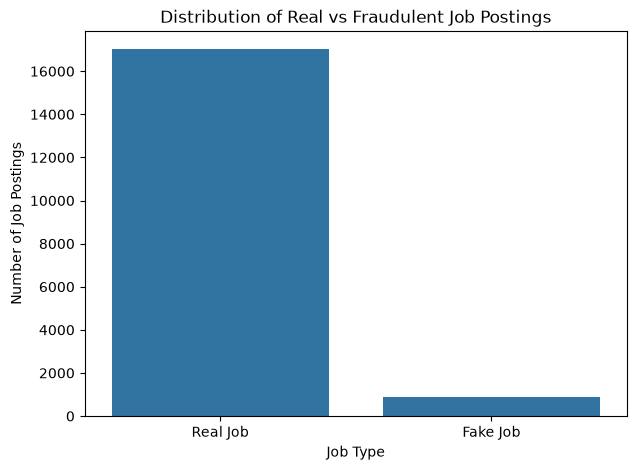

In [41]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="fraudulent"
)

plt.title("Distribution of Real vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

ax.set_xticklabels(["Real Job", "Fake Job"])

plt.show()

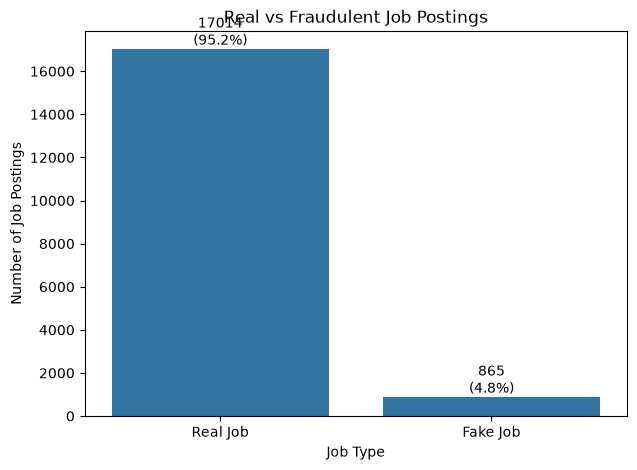

In [42]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="fraudulent"
)

plt.title("Real vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

total = len(df)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.0f}\n"
        f"({bar.get_height()/total*100:.1f}%)"
        for bar in container
    ]
    ax.bar_label(container, labels=labels)

ax.set_xticklabels(["Real Job", "Fake Job"])

plt.show()

In [43]:
real_count = (df["fraudulent"] == 0).sum()
fake_count = (df["fraudulent"] == 1).sum()

imbalance_ratio = real_count / fake_count

print("Real Jobs :", real_count)
print("Fake Jobs :", fake_count)
print("Imbalance Ratio :", round(imbalance_ratio, 2))

Real Jobs : 17014
Fake Jobs : 865
Imbalance Ratio : 19.67


## Target Variable Analysis

The target variable `fraudulent` contains two classes:

- 0 → Real job posting
- 1 → Fraudulent job posting

The dataset shows class imbalance between legitimate and fraudulent
job postings. Therefore, model evaluation should not rely solely on
accuracy. Precision, recall, F1-score, ROC-AUC and PR-AUC will be
considered during model evaluation.

In [44]:
df["has_company_profile"].value_counts()

has_company_profile
1    14572
0     3307
Name: count, dtype: int64

In [45]:
company_profile_analysis = pd.crosstab(
    df["has_company_profile"],
    df["fraudulent"],
    normalize="index"
) * 100

company_profile_analysis

fraudulent,0,1
has_company_profile,,
0,82.280012,17.719988
1,98.085369,1.914631


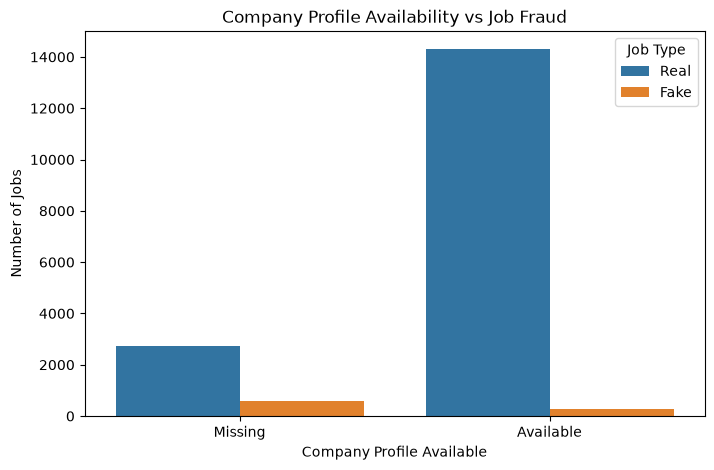

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="has_company_profile",
    hue="fraudulent"
)

plt.title("Company Profile Availability vs Job Fraud")
plt.xlabel("Company Profile Available")
plt.ylabel("Number of Jobs")

plt.xticks(
    [0, 1],
    ["Missing", "Available"]
)

plt.legend(
    title="Job Type",
    labels=["Real", "Fake"]
)

plt.show()

In [47]:
company_fraud_rate = (
    df.groupby("has_company_profile")["fraudulent"]
    .mean()
    * 100
)

company_fraud_rate

has_company_profile
0    17.719988
1     1.914631
Name: fraudulent, dtype: float64

In [48]:
df["has_salary"].value_counts()

has_salary
0    15011
1     2868
Name: count, dtype: int64

In [49]:
salary_analysis = pd.crosstab(
    df["has_salary"],
    df["fraudulent"],
    normalize="index"
) * 100

salary_analysis

fraudulent,0,1
has_salary,,
0,95.723136,4.276864
1,92.224547,7.775453


In [50]:
salary_fraud_rate = (
    df.groupby("has_salary")["fraudulent"]
    .mean()
    * 100
)

salary_fraud_rate

has_salary
0    4.276864
1    7.775453
Name: fraudulent, dtype: float64

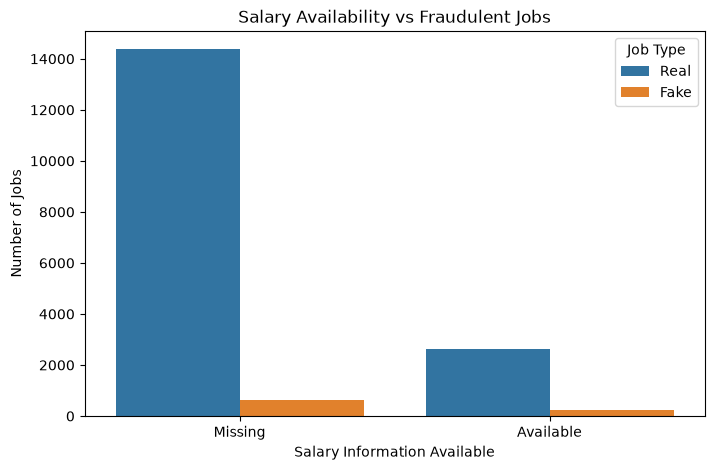

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="has_salary",
    hue="fraudulent"
)

plt.title("Salary Availability vs Fraudulent Jobs")
plt.xlabel("Salary Information Available")
plt.ylabel("Number of Jobs")

plt.xticks(
    [0, 1],
    ["Missing", "Available"]
)

plt.legend(
    title="Job Type",
    labels=["Real", "Fake"]
)

plt.show()

In [52]:
requirements_analysis = pd.crosstab(
    df["has_requirements"],
    df["fraudulent"],
    normalize="index"
) * 100

requirements_analysis

fraudulent,0,1
has_requirements,,
0,94.327030,5.672970
1,95.310236,4.689764


In [53]:
df.groupby("has_requirements")["fraudulent"].mean() * 100

has_requirements
0    5.672970
1    4.689764
Name: fraudulent, dtype: float64

In [54]:
benefits_analysis = pd.crosstab(
    df["has_benefits"],
    df["fraudulent"],
    normalize="index"
) * 100

benefits_analysis

fraudulent,0,1
has_benefits,,
0,94.971603,5.028397
1,95.290807,4.709193


In [55]:
df.groupby("has_benefits")["fraudulent"].mean() * 100

has_benefits
0    5.028397
1    4.709193
Name: fraudulent, dtype: float64

In [56]:
missing_info_count = [
    "has_salary",
    "has_company_profile",
    "has_requirements",
    "has_benefits"
]

In [57]:
df["missing_info_count"] = (
    4 - df[missing_info_count].sum(axis=1)
)

In [58]:
df["missing_info_count"].value_counts().sort_index()

missing_info_count
0    1634
1    8023
2    5031
3    2615
4     576
Name: count, dtype: int64

In [59]:
missing_fraud_rate = (
    df.groupby("missing_info_count")["fraudulent"]
    .mean()
    * 100
)

missing_fraud_rate

missing_info_count
0     5.569155
1     2.654867
2     5.545617
3     5.927342
4    22.048611
Name: fraudulent, dtype: float64

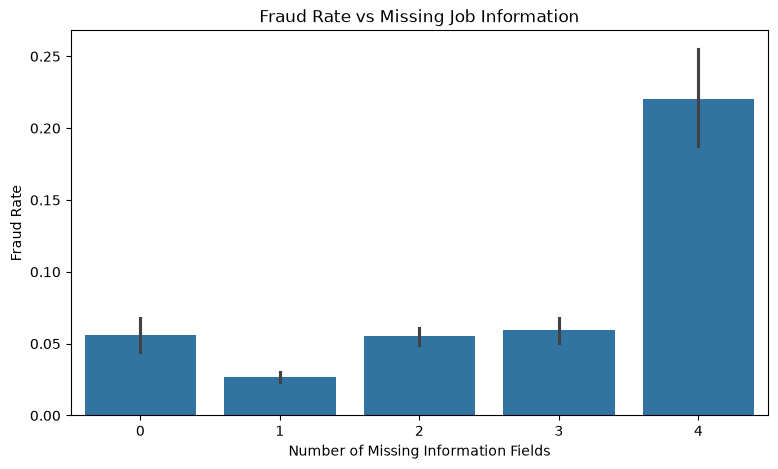

In [60]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="missing_info_count",
    y="fraudulent"
)

plt.title("Fraud Rate vs Missing Job Information")
plt.xlabel("Number of Missing Information Fields")
plt.ylabel("Fraud Rate")

plt.show()

## Missing Information Analysis

We analyzed the relationship between missing job-posting information
and fraudulent job postings.

The analysis included:

- Company profile availability
- Salary information availability
- Requirements availability
- Benefits availability

We also created `missing_info_count` to measure how much information
is missing from each job posting.

These features may provide useful signals for the machine learning model.
However, correlation or association does not imply causation.

In [61]:
df["employment_type"].value_counts()

employment_type
Full-time    11620
Unknown       3470
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [62]:
df["employment_type"].value_counts()

employment_type
Full-time    11620
Unknown       3470
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [63]:
df["employment_type"].value_counts(normalize=True) * 100

employment_type
Full-time    64.992449
Unknown      19.408244
Contract      8.523967
Part-time     4.457744
Temporary     1.347950
Other         1.269646
Name: proportion, dtype: float64

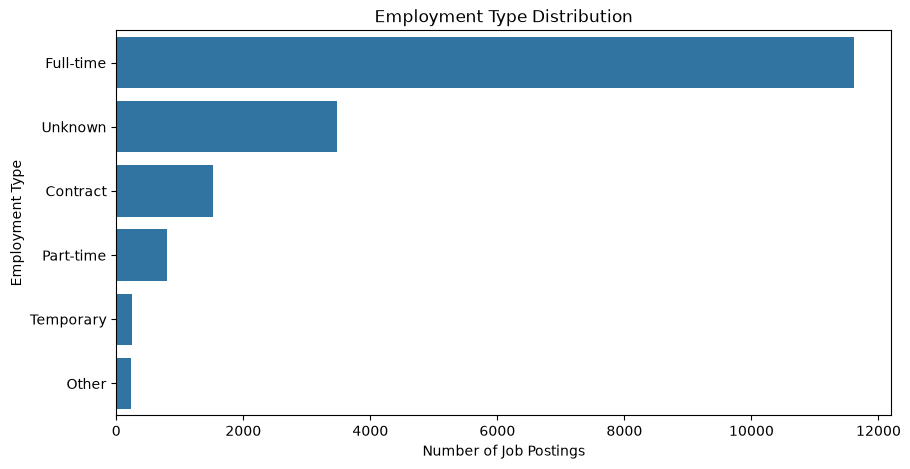

In [64]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="employment_type",
    order=df["employment_type"].value_counts().index
)

plt.title("Employment Type Distribution")
plt.xlabel("Number of Job Postings")
plt.ylabel("Employment Type")

plt.show()

In [65]:
employment_fraud = pd.crosstab(
    df["employment_type"],
    df["fraudulent"],
    normalize="index"
) * 100

employment_fraud

fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876
Unknown,93.083573,6.916427


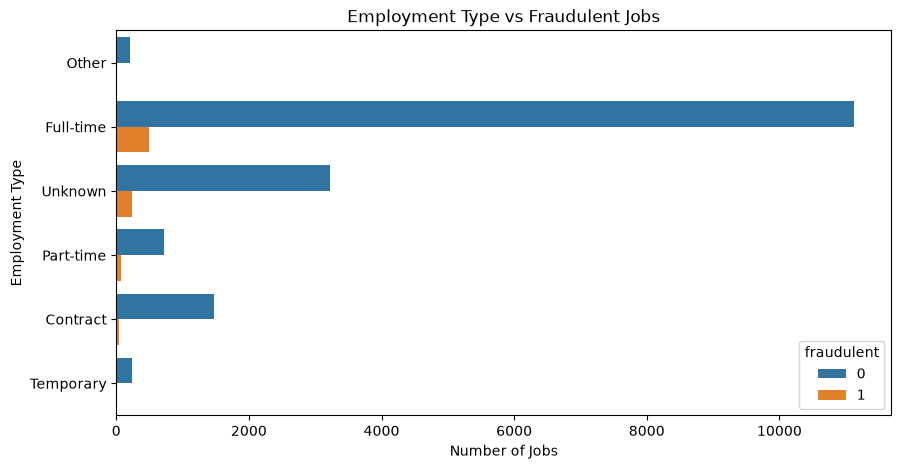

In [66]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="employment_type",
    hue="fraudulent"
)

plt.title("Employment Type vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Employment Type")

plt.show()

In [67]:
employment_fraud_rate = (
    df.groupby("employment_type")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

employment_fraud_rate

employment_type
Part-time    9.284818
Unknown      6.916427
Other        6.607930
Full-time    4.216867
Contract     2.887139
Temporary    0.829876
Name: fraudulent, dtype: float64

## Employment Type — Findings

- The distribution of job postings varies across employment types.
- Fraud rates differ across employment categories.
- The employment type feature may provide useful information for fraud detection.

The observed differences represent associations in the dataset and do not
necessarily imply that employment type causes fraudulent postings.

In [68]:
df["required_experience"].value_counts()

required_experience
Unknown             7049
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

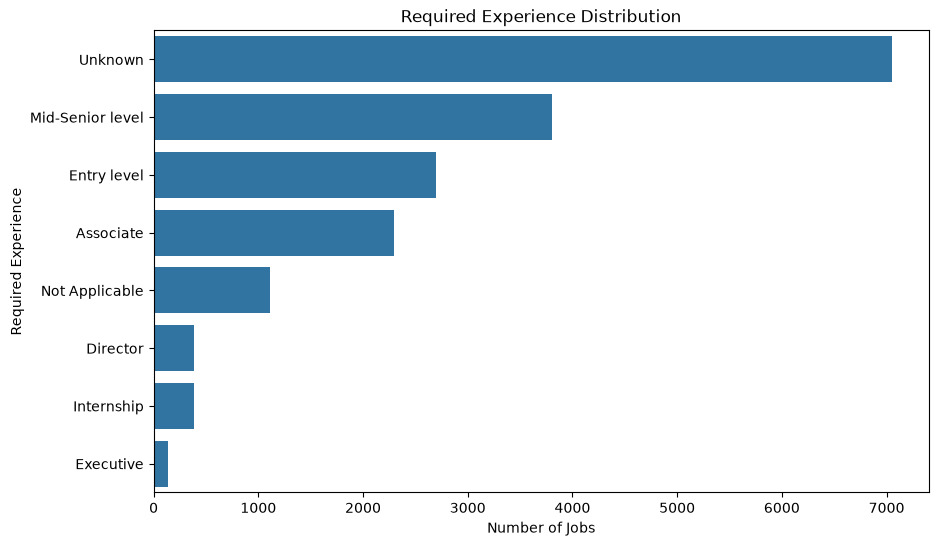

In [69]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="required_experience",
    order=df["required_experience"].value_counts().index
)

plt.title("Required Experience Distribution")
plt.xlabel("Number of Jobs")
plt.ylabel("Required Experience")

plt.show()

In [70]:
experience_fraud = pd.crosstab(
    df["required_experience"],
    df["fraudulent"],
    normalize="index"
) * 100

experience_fraud

fraudulent,0,1
required_experience,,
Associate,98.171528,1.828472
Director,95.629820,4.370180
Entry level,93.362996,6.637004
Executive,92.907801,7.092199
Internship,97.375328,2.624672
Mid-Senior level,97.033342,2.966658
Not Applicable,94.623656,5.376344
Unknown,93.843098,6.156902


In [71]:
experience_fraud_rate = (
    df.groupby("required_experience")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

experience_fraud_rate

required_experience
Executive           7.092199
Entry level         6.637004
Unknown             6.156902
Not Applicable      5.376344
Director            4.370180
Mid-Senior level    2.966658
Internship          2.624672
Associate           1.828472
Name: fraudulent, dtype: float64

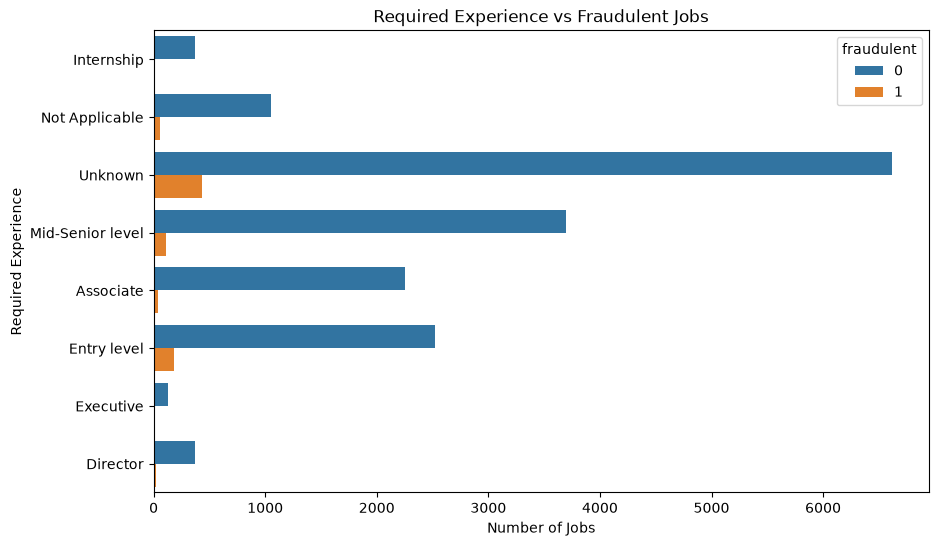

In [72]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="required_experience",
    hue="fraudulent"
)

plt.title("Required Experience vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Required Experience")

plt.show()

In [73]:
df["required_education"].value_counts()

required_education
Unknown                              8104
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

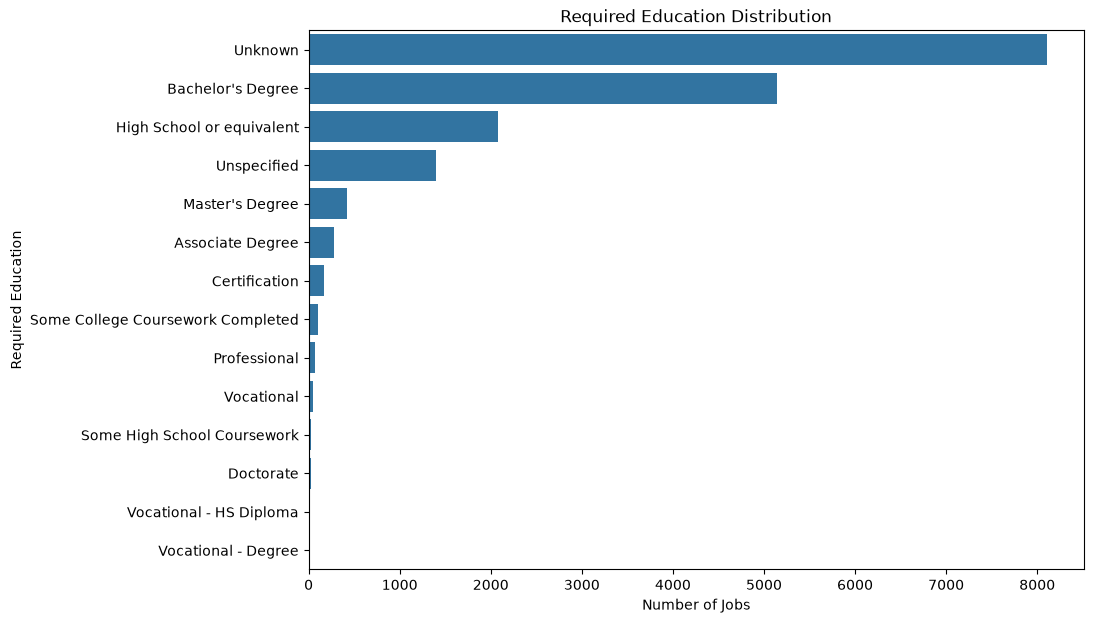

In [74]:
plt.figure(figsize=(10, 7))

sns.countplot(
    data=df,
    y="required_education",
    order=df["required_education"].value_counts().index
)

plt.title("Required Education Distribution")
plt.xlabel("Number of Jobs")
plt.ylabel("Required Education")

plt.show()

In [75]:
education_fraud = pd.crosstab(
    df["required_education"],
    df["fraudulent"],
    normalize="index"
) * 100

education_fraud

fraudulent,0,1
required_education,,
Associate Degree,97.810219,2.189781
Bachelor's Degree,98.056365,1.943635
Certification,88.823529,11.176471
Doctorate,96.153846,3.846154
High School or equivalent,91.826923,8.173077
Master's Degree,92.548077,7.451923
Professional,94.594595,5.405405
Some College Coursework Completed,97.058824,2.941176
Some High School Coursework,25.925926,74.074074


In [76]:
education_fraud_rate = (
    df.groupby("required_education")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

education_fraud_rate

required_education
Some High School Coursework          74.074074
Certification                        11.176471
High School or equivalent             8.173077
Master's Degree                       7.451923
Unknown                               5.552813
Professional                          5.405405
Unspecified                           4.366500
Doctorate                             3.846154
Some College Coursework Completed     2.941176
Associate Degree                      2.189781
Bachelor's Degree                     1.943635
Vocational                            0.000000
Vocational - Degree                   0.000000
Vocational - HS Diploma               0.000000
Name: fraudulent, dtype: float64

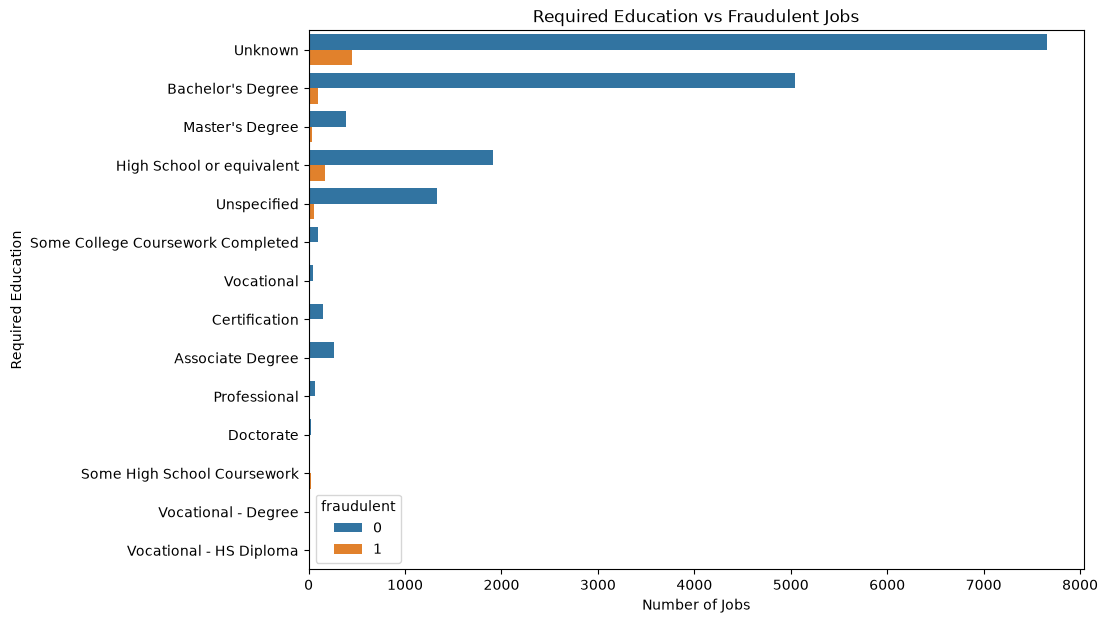

In [77]:
plt.figure(figsize=(10, 7))

sns.countplot(
    data=df,
    y="required_education",
    hue="fraudulent"
)

plt.title("Required Education vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Required Education")

plt.show()

In [78]:
df["industry"].nunique()

132

In [79]:
df["industry"].value_counts().head(20)

industry
Unknown                                4902
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Management Consulting                   130
Design                                  129
Health, Wellness and Fitness            127
Staffing and Recruiting                 127
Name: count, dtype: int64

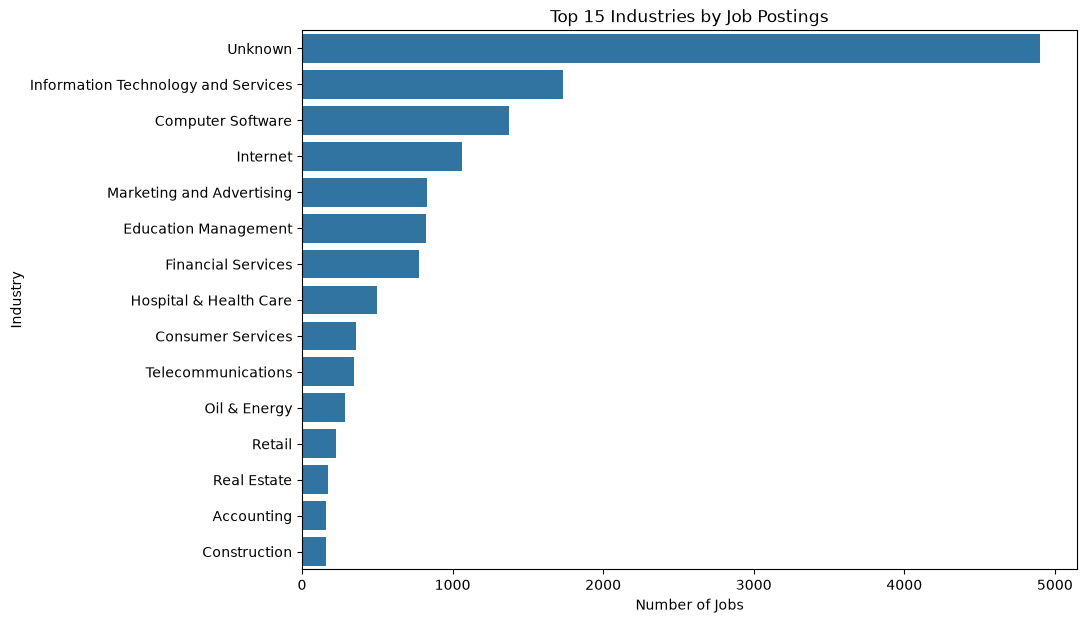

In [80]:
top_industries = df["industry"].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_industries.values,
    y=top_industries.index
)

plt.title("Top 15 Industries by Job Postings")
plt.xlabel("Number of Jobs")
plt.ylabel("Industry")

plt.show()

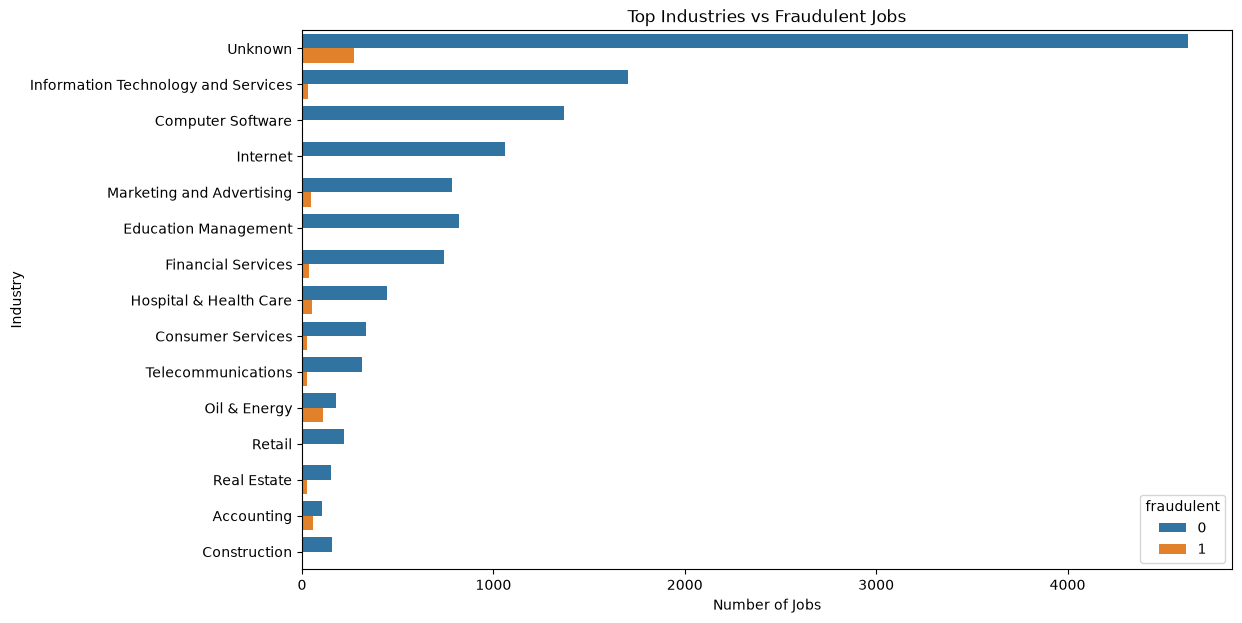

In [81]:
top_industry_names = df["industry"].value_counts().head(15).index

industry_subset = df[
    df["industry"].isin(top_industry_names)
]

plt.figure(figsize=(12, 7))

sns.countplot(
    data=industry_subset,
    y="industry",
    hue="fraudulent",
    order=top_industry_names
)

plt.title("Top Industries vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Industry")

plt.show()

In [82]:
industry_fraud_rate = (
    industry_subset
    .groupby("industry")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

industry_fraud_rate

industry
Oil & Energy                           37.979094
Accounting                             35.849057
Real Estate                            13.714286
Hospital & Health Care                 10.261569
Telecommunications                      7.602339
Consumer Services                       6.703911
Unknown                                 5.589555
Marketing and Advertising               5.434783
Financial Services                      4.492940
Retail                                  2.242152
Construction                            1.898734
Information Technology and Services     1.845444
Computer Software                       0.363372
Education Management                    0.000000
Internet                                0.000000
Name: fraudulent, dtype: float64

In [83]:
df["function"].nunique()

38

In [84]:
df["function"].value_counts().head(20)

function
Unknown                   6454
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Art/Creative               132
Writing/Editing            132
Name: count, dtype: int64

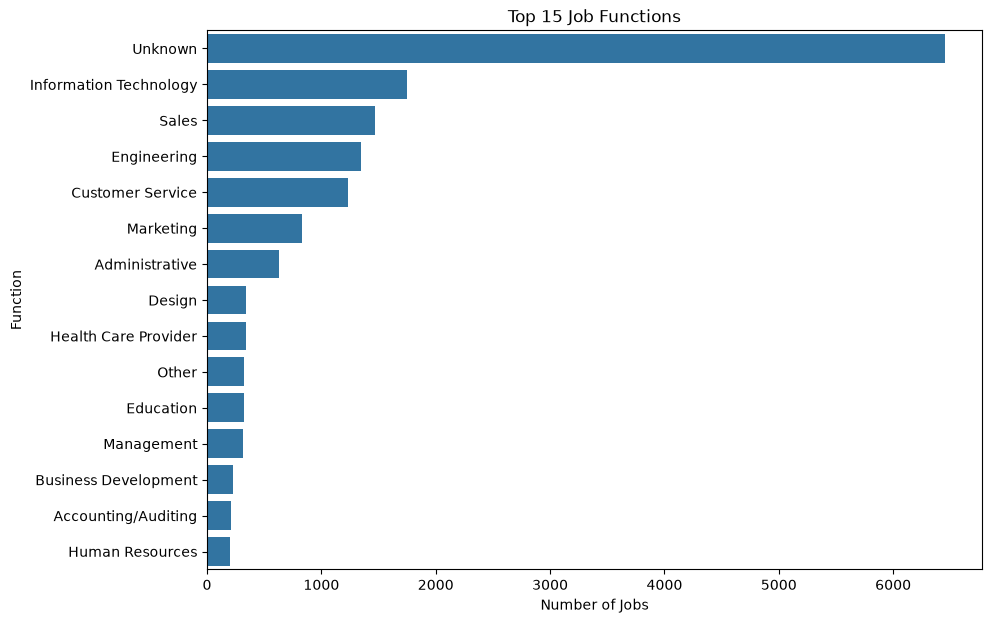

In [85]:
top_functions = df["function"].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_functions.values,
    y=top_functions.index
)

plt.title("Top 15 Job Functions")
plt.xlabel("Number of Jobs")
plt.ylabel("Function")

plt.show()

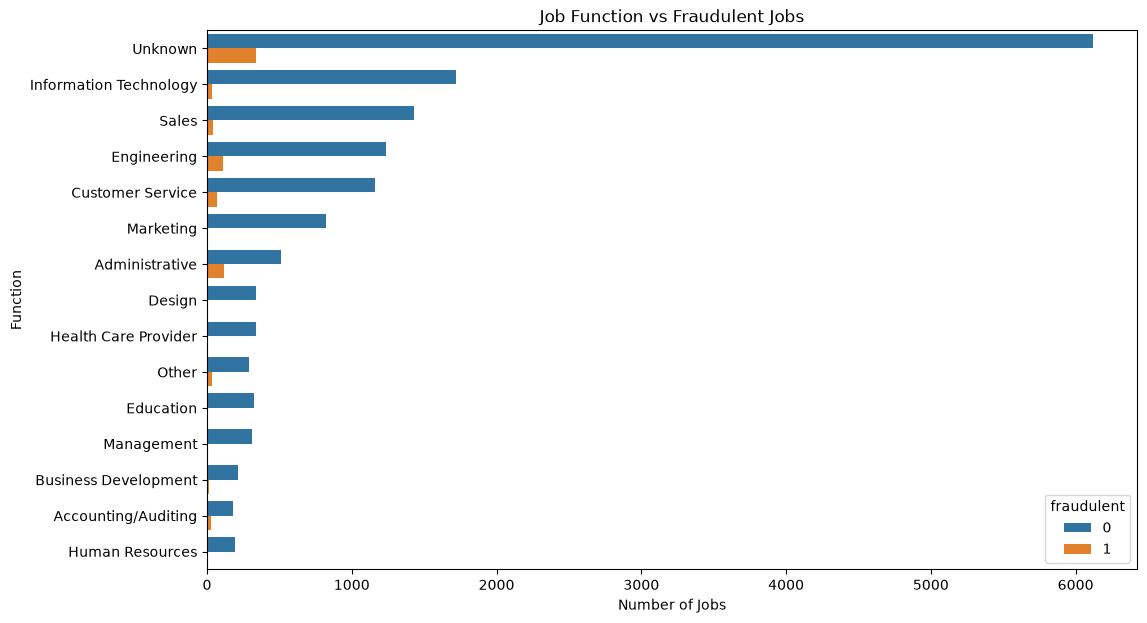

In [86]:
top_function_names = df["function"].value_counts().head(15).index

function_subset = df[
    df["function"].isin(top_function_names)
]

plt.figure(figsize=(12, 7))

sns.countplot(
    data=function_subset,
    y="function",
    hue="fraudulent",
    order=top_function_names
)

plt.title("Job Function vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Function")

plt.show()

In [87]:
function_fraud_rate = (
    function_subset
    .groupby("function")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

function_fraud_rate

function
Administrative            18.888889
Accounting/Auditing       13.679245
Other                      9.846154
Engineering                8.382789
Business Development       5.701754
Customer Service           5.451587
Unknown                    5.206074
Human Resources            4.390244
Sales                      2.792916
Management                 1.892744
Information Technology     1.829617
Marketing                  1.204819
Design                     0.882353
Education                  0.307692
Health Care Provider       0.295858
Name: fraudulent, dtype: float64

In [88]:
df["location"].nunique()

3106

In [89]:
df["location"].value_counts().head(20)

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
Unknown                  346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
GB, ,                    138
US, GA, Atlanta          135
GB, LND,                 131
US, OR, Portland         131
CA, ON, Toronto          123
Name: count, dtype: int64

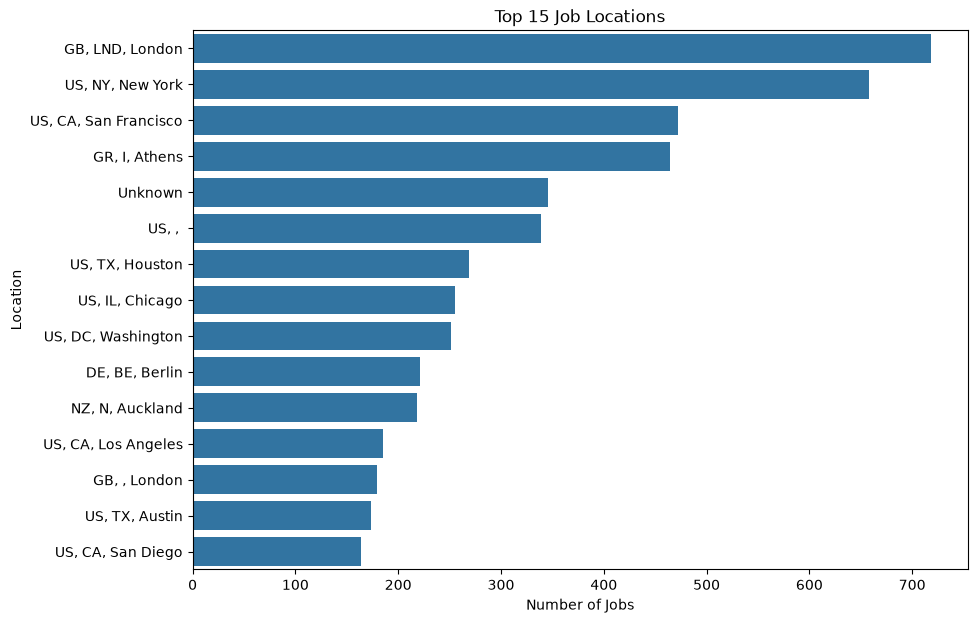

In [90]:
top_locations = df["location"].value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 15 Job Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")

plt.show()

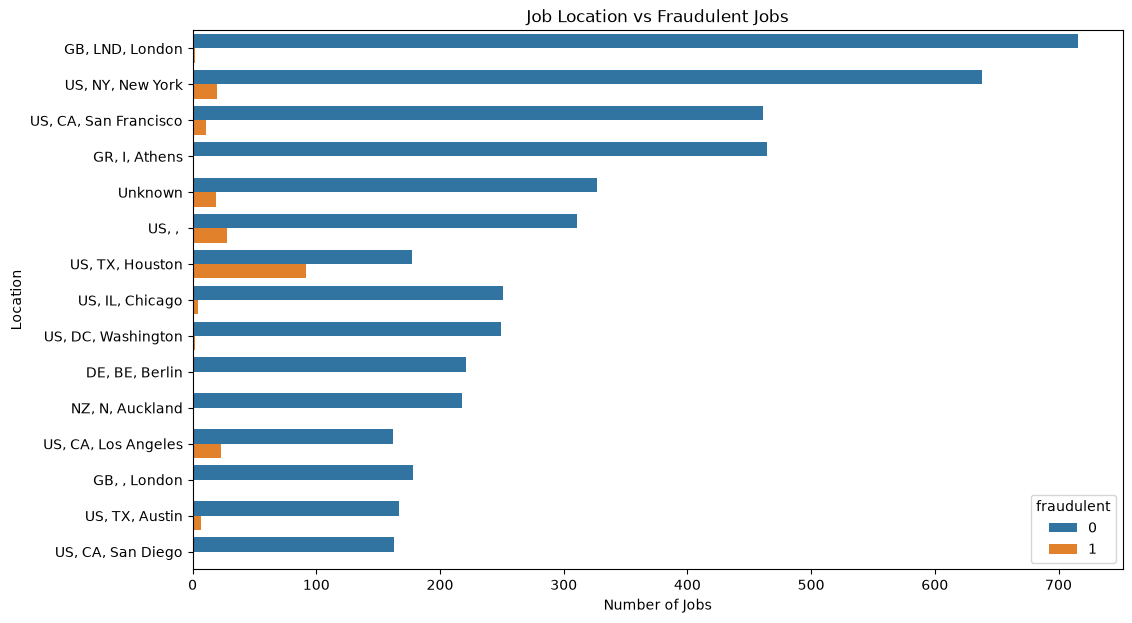

In [91]:
top_location_names = df["location"].value_counts().head(15).index

location_subset = df[
    df["location"].isin(top_location_names)
]

plt.figure(figsize=(12, 7))

sns.countplot(
    data=location_subset,
    y="location",
    hue="fraudulent",
    order=top_location_names
)

plt.title("Job Location vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")

plt.show()

In [92]:
location_fraud_rate = (
    location_subset
    .groupby("location")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

location_fraud_rate

location
US, TX, Houston          34.200743
US, CA, Los Angeles      12.432432
US, ,                     8.259587
Unknown                   5.491329
US, TX, Austin            4.022989
US, NY, New York          3.039514
US, CA, San Francisco     2.330508
US, IL, Chicago           1.568627
US, DC, Washington        0.796813
US, CA, San Diego         0.609756
GB, , London              0.558659
GB, LND, London           0.278552
GR, I, Athens             0.000000
DE, BE, Berlin            0.000000
NZ, N, Auckland           0.000000
Name: fraudulent, dtype: float64

In [93]:
df["department"].nunique()

1337

In [94]:
top_departments = df["department"].value_counts().head(15)

top_departments

department
Unknown                   11547
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Design                       76
Technology                   76
Customer Service             73
Finance                      69
HR                           56
tech                         55
Name: count, dtype: int64

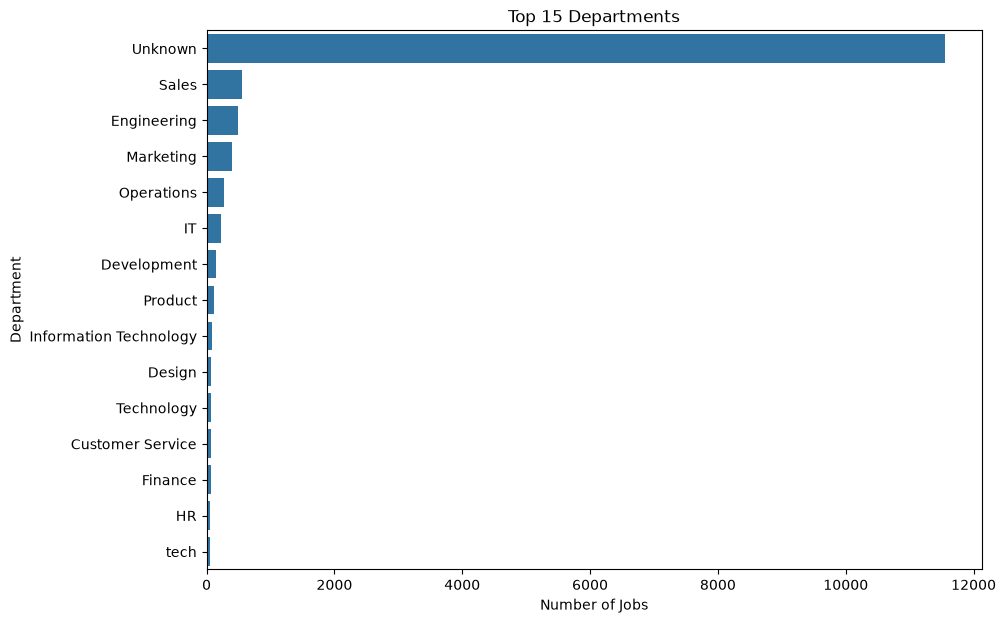

In [95]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_departments.values,
    y=top_departments.index
)

plt.title("Top 15 Departments")
plt.xlabel("Number of Jobs")
plt.ylabel("Department")

plt.show()

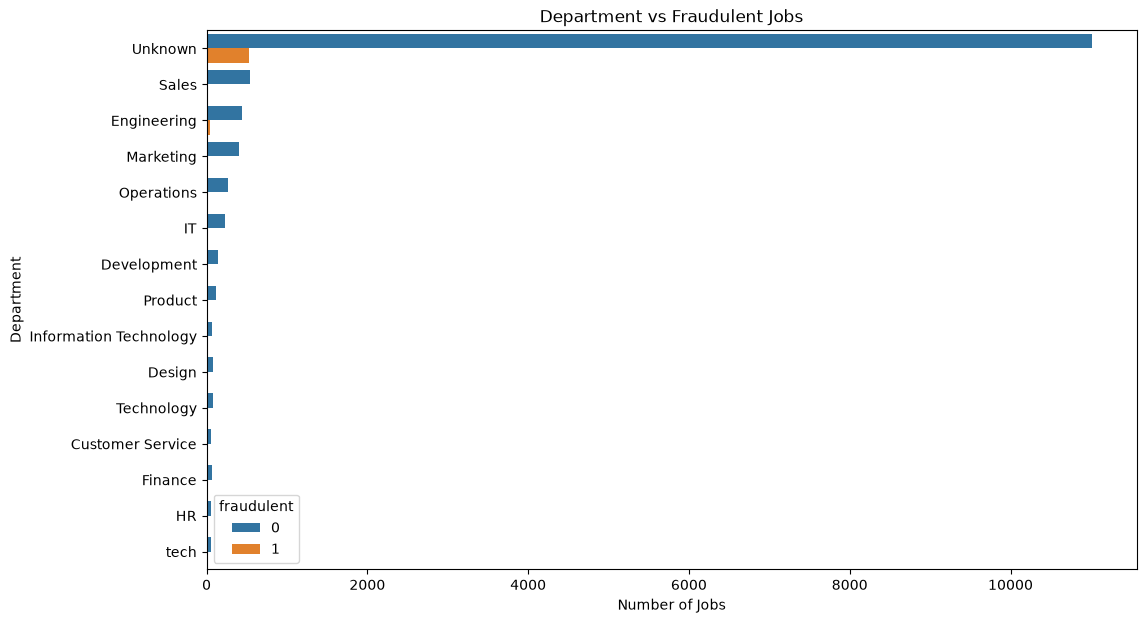

In [96]:
top_department_names = df["department"].value_counts().head(15).index

department_subset = df[
    df["department"].isin(top_department_names)
]

plt.figure(figsize=(12, 7))

sns.countplot(
    data=department_subset,
    y="department",
    hue="fraudulent",
    order=top_department_names
)

plt.title("Department vs Fraudulent Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Department")

plt.show()

In [97]:
department_fraud_rate = (
    department_subset
    .groupby("department")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

department_fraud_rate

department
Customer Service          19.178082
Information Technology    17.441860
Engineering                9.445585
HR                         5.357143
Unknown                    4.589937
Sales                      2.177858
Technology                 1.315789
Marketing                  0.498753
IT                         0.444444
Design                     0.000000
Development                0.000000
Finance                    0.000000
Operations                 0.000000
Product                    0.000000
tech                       0.000000
Name: fraudulent, dtype: float64

# Categorical Features — Overall Findings

We analyzed the major categorical features of the job-posting dataset:

- Employment Type
- Required Experience
- Required Education
- Industry
- Function
- Location
- Department

For each feature, we examined its overall distribution, relationship with
the target variable, and fraudulent-job rate.

Some categories showed different fraud rates compared with others. However,
categories with very few observations were treated carefully because their
fraud rates may not be statistically reliable.

These categorical features will be considered during model development after
appropriate preprocessing and encoding.

In [98]:
df["title_length"] = df["title"].str.len()

In [99]:
df["title_length"].describe()

count    17879.000000
mean        28.531126
std         13.871218
min          3.000000
25%         19.000000
50%         25.000000
75%         35.000000
max        142.000000
Name: title_length, dtype: float64

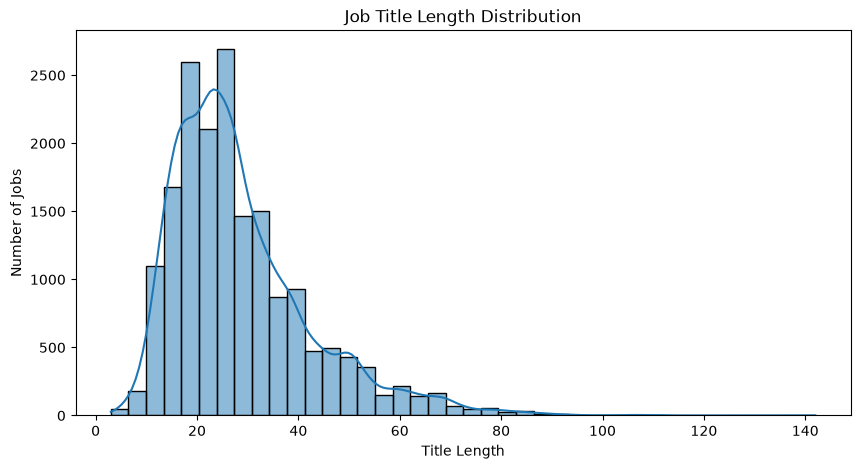

In [100]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="title_length",
    bins=40,
    kde=True
)

plt.title("Job Title Length Distribution")
plt.xlabel("Title Length")
plt.ylabel("Number of Jobs")

plt.show()

In [101]:
df["description_length"] = df["description"].str.len()

In [102]:
df["description_length"].describe()

count    17879.000000
mean      1218.072543
std        894.807276
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: description_length, dtype: float64

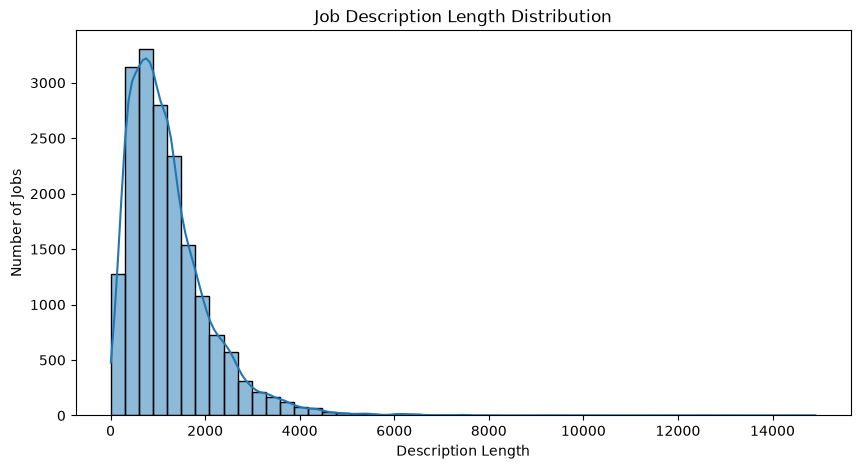

In [103]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="description_length",
    bins=50,
    kde=True
)

plt.title("Job Description Length Distribution")
plt.xlabel("Description Length")
plt.ylabel("Number of Jobs")

plt.show()

In [104]:
df["requirements_length"] = df["requirements"].str.len()

In [105]:
df["requirements_length"].describe()

count    17879.000000
mean       590.165222
std        613.192535
min          0.000000
25%        146.000000
50%        467.000000
75%        820.000000
max      10864.000000
Name: requirements_length, dtype: float64

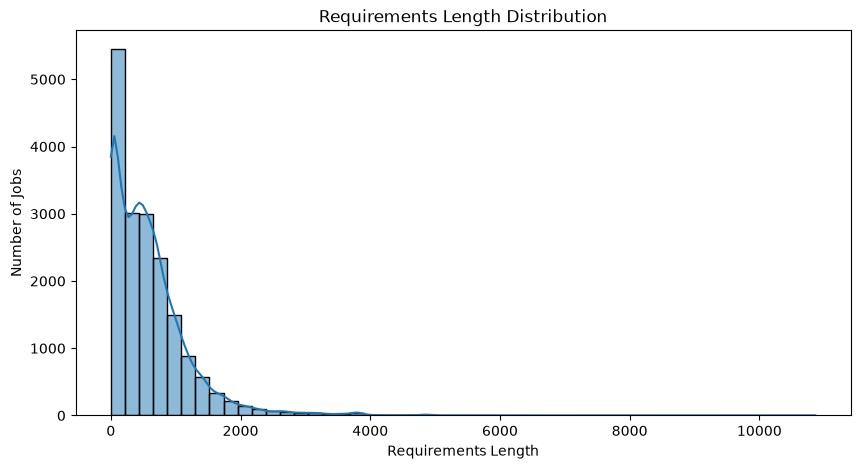

In [106]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="requirements_length",
    bins=50,
    kde=True
)

plt.title("Requirements Length Distribution")
plt.xlabel("Requirements Length")
plt.ylabel("Number of Jobs")

plt.show()

In [107]:
df["benefits_length"] = df["benefits"].str.len()

In [108]:
df["benefits_length"].describe()

count    17879.000000
mean       208.907377
std        337.083163
min          0.000000
25%          0.000000
50%         45.000000
75%        294.000000
max       4429.000000
Name: benefits_length, dtype: float64

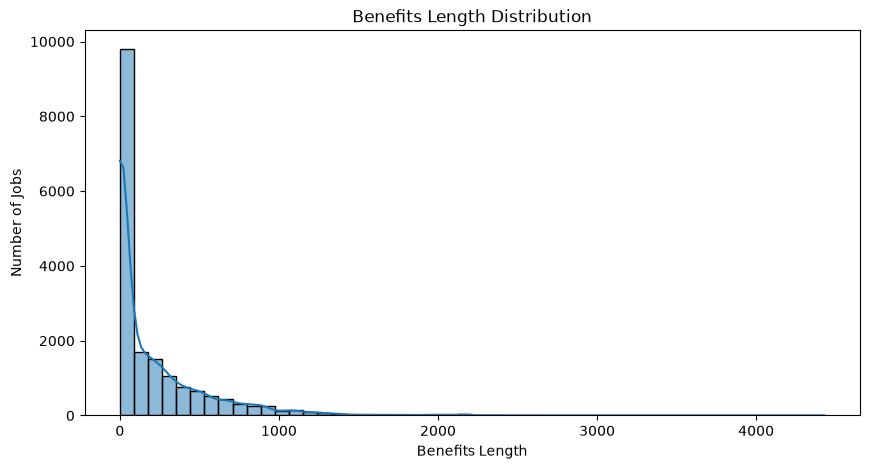

In [109]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="benefits_length",
    bins=50,
    kde=True
)

plt.title("Benefits Length Distribution")
plt.xlabel("Benefits Length")
plt.ylabel("Number of Jobs")

plt.show()

In [110]:
df["company_profile_length"] = df["company_profile"].str.len()

In [111]:
df["company_profile_length"].describe()

count    17879.000000
mean       620.936182
std        567.450968
min          0.000000
25%        138.000000
50%        570.000000
75%        879.000000
max       6178.000000
Name: company_profile_length, dtype: float64

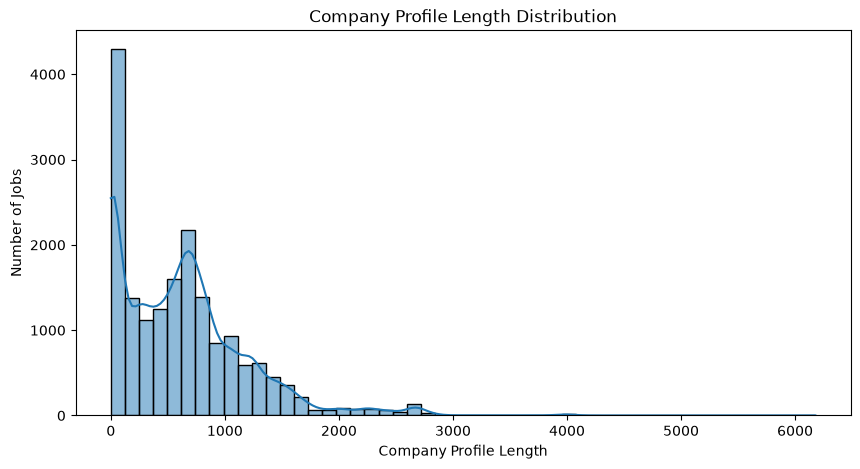

In [112]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="company_profile_length",
    bins=50,
    kde=True
)

plt.title("Company Profile Length Distribution")
plt.xlabel("Company Profile Length")
plt.ylabel("Number of Jobs")

plt.show()

In [113]:
df.groupby("fraudulent")["description_length"].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,1221.219701,889.139777,6.0,616.0,1027.0,1589.0,14907.0
1,865.0,1156.169942,998.329255,9.0,467.0,846.0,1541.0,8578.0


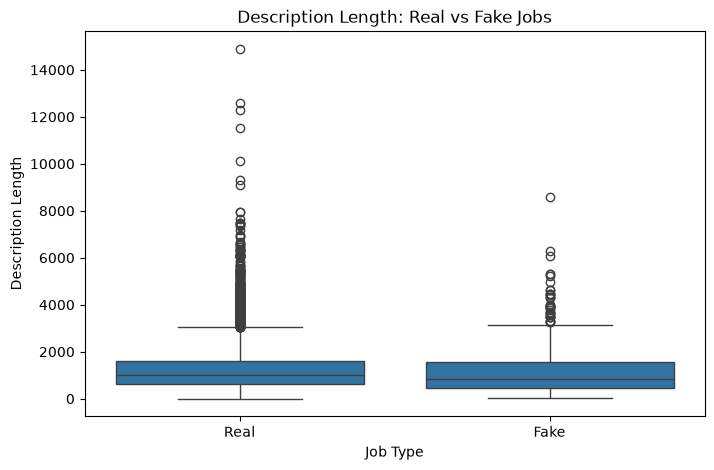

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_length"
)

plt.title("Description Length: Real vs Fake Jobs")
plt.xlabel("Job Type")
plt.ylabel("Description Length")

plt.xticks(
    [0, 1],
    ["Real", "Fake"]
)

plt.show()

In [115]:
df.groupby("fraudulent")["description_length"].mean()

fraudulent
0    1221.219701
1    1156.169942
Name: description_length, dtype: float64

In [116]:
df.groupby("fraudulent")["requirements_length"].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,597.465910,614.368278,0.0,153.0,476.5,830.0,10864.0
1,865.0,446.565318,571.249484,0.0,47.0,249.0,651.0,4077.0


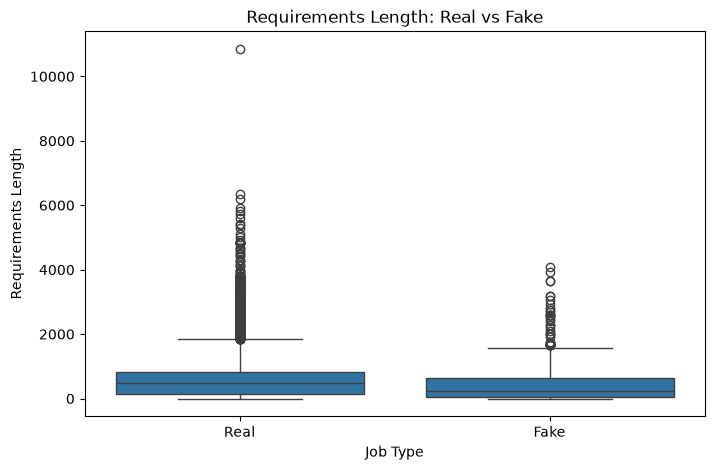

In [117]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="requirements_length"
)

plt.title("Requirements Length: Real vs Fake")
plt.xlabel("Job Type")
plt.ylabel("Requirements Length")

plt.xticks(
    [0, 1],
    ["Real", "Fake"]
)

plt.show()

In [118]:
df.groupby("fraudulent")["benefits_length"].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,208.727695,335.185462,0.0,0.0,47.0,295.0,4429.0
1,865.0,212.441618,372.645251,0.0,0.0,37.0,255.0,2500.0


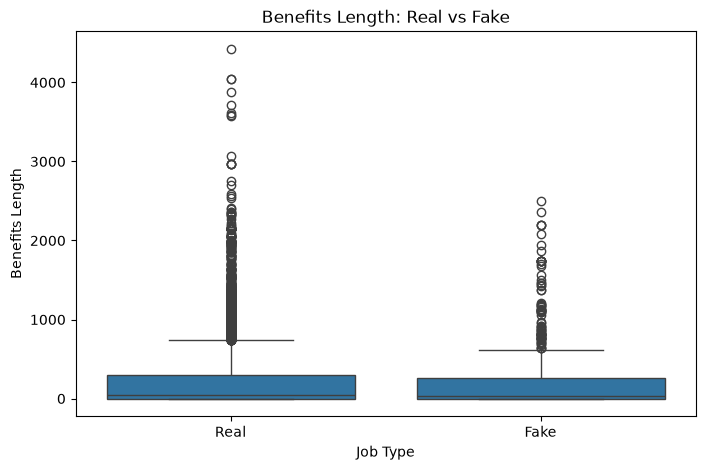

In [119]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="benefits_length"
)

plt.title("Benefits Length: Real vs Fake")
plt.xlabel("Job Type")
plt.ylabel("Benefits Length")

plt.xticks(
    [0, 1],
    ["Real", "Fake"]
)

plt.show()

In [120]:
df.groupby("fraudulent")["company_profile_length"].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,640.752674,568.226522,0.0,228.0,588.0,879.0,6178.0
1,865.0,231.158382,381.043762,0.0,0.0,0.0,415.0,1422.0


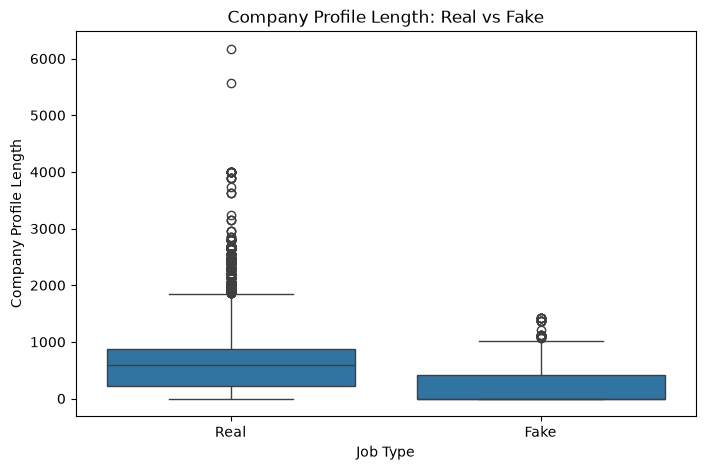

In [121]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="company_profile_length"
)

plt.title("Company Profile Length: Real vs Fake")
plt.xlabel("Job Type")
plt.ylabel("Company Profile Length")

plt.xticks(
    [0, 1],
    ["Real", "Fake"]
)

plt.show()

In [122]:
text_length_columns = [
    "title_length",
    "description_length",
    "requirements_length",
    "benefits_length",
    "company_profile_length"
]

text_length_summary = (
    df.groupby("fraudulent")[text_length_columns]
    .mean()
    .T
)

text_length_summary.columns = ["Real", "Fake"]

text_length_summary

,Real,Fake
title_length,28.421594,30.685549
description_length,1221.219701,1156.169942
requirements_length,597.465910,446.565318
benefits_length,208.727695,212.441618
company_profile_length,640.752674,231.158382


In [123]:
from sklearn.feature_extraction.text import CountVectorizer

In [124]:
real_text = " ".join(
    df.loc[df["fraudulent"] == 0, "description"]
)

fake_text = " ".join(
    df.loc[df["fraudulent"] == 1, "description"]
)

In [125]:
vectorizer_real = CountVectorizer(
    stop_words="english",
    max_features=30
)

real_matrix = vectorizer_real.fit_transform([real_text])

real_words = pd.DataFrame({
    "word": vectorizer_real.get_feature_names_out(),
    "count": real_matrix.toarray()[0]
})

real_words = real_words.sort_values(
    "count",
    ascending=False
)

real_words

,word,count
26,team,18257
28,work,14422
2,business,10474
11,experience,9956
5,company,9706
17,new,9451
6,customer,9428
21,sales,9327
14,looking,8346
10,development,7967


In [126]:
vectorizer_fake = CountVectorizer(
    stop_words="english",
    max_features=30
)

fake_matrix = vectorizer_fake.fit_transform([fake_text])

fake_words = pd.DataFrame({
    "word": vectorizer_fake.get_feature_names_out(),
    "count": fake_matrix.toarray()[0]
})

fake_words = fake_words.sort_values(
    "count",
    ascending=False
)

fake_words

,word,count
29,work,1052
0,amp,695
27,team,522
8,experience,496
2,company,491
28,time,489
14,position,477
11,management,464
17,project,454
3,customer,453


In [127]:
from wordcloud import WordCloud

In [128]:
fake_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords="english"
).generate(fake_text)

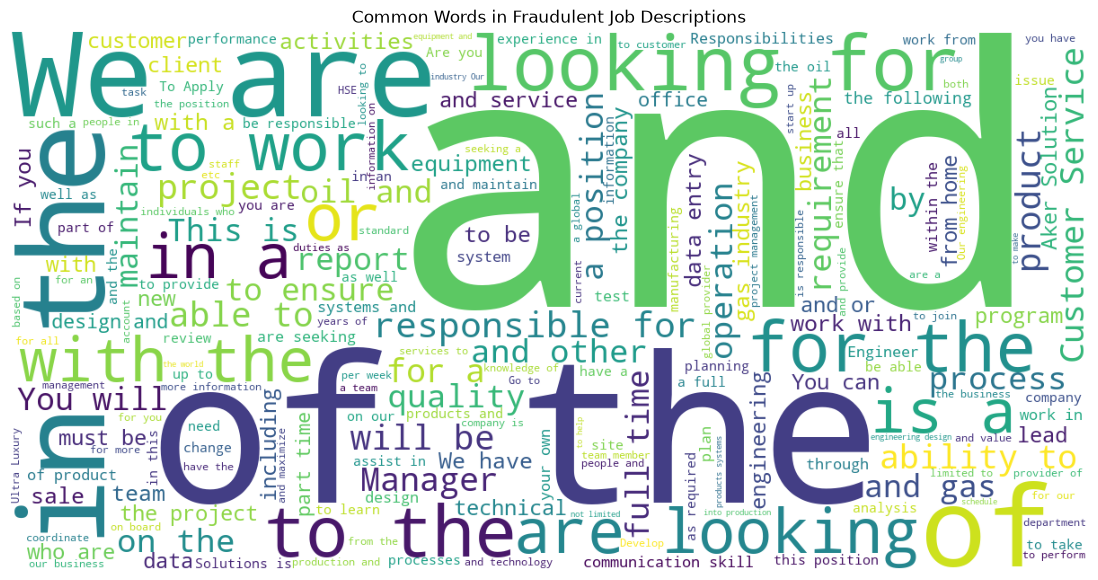

In [129]:
plt.figure(figsize=(15, 7))

plt.imshow(fake_wordcloud)

plt.axis("off")

plt.title("Common Words in Fraudulent Job Descriptions")

plt.show()

In [130]:
real_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords="english"
).generate(real_text)

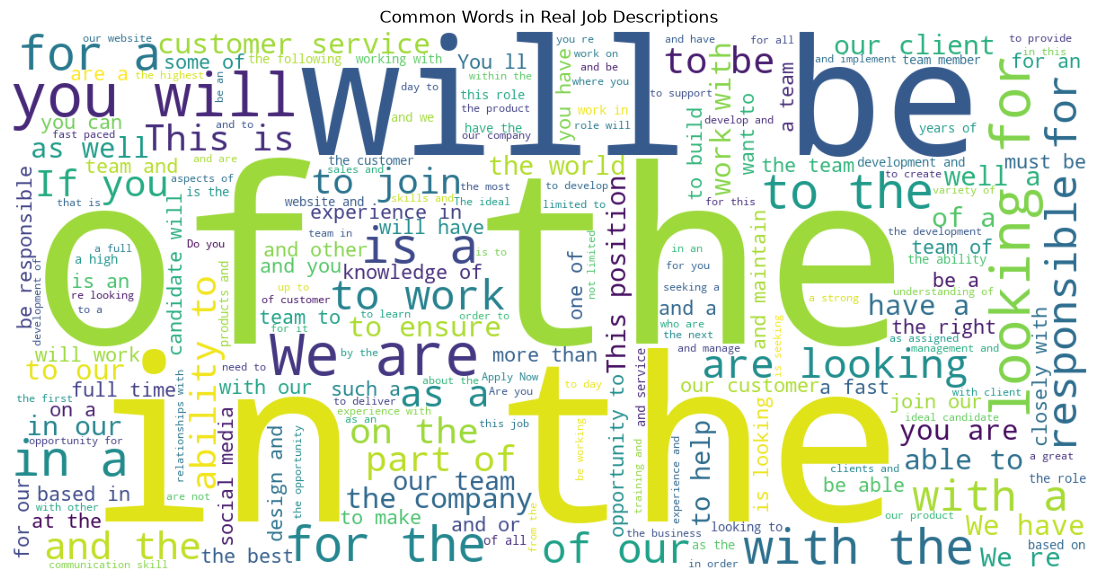

In [131]:
plt.figure(figsize=(15, 7))

plt.imshow(real_wordcloud)

plt.axis("off")

plt.title("Common Words in Real Job Descriptions")

plt.show()

In [132]:
suspicious_words = [
    "urgent",
    "immediate",
    "easy",
    "money",
    "cash",
    "earn",
    "guaranteed",
    "work from home",
    "no experience",
    "quick",
    "hiring",
    "investment",
    "income",
    "commission"
]

In [133]:
def keyword_presence(text, keyword):
    return int(
        keyword.lower() in text.lower()
    )

In [134]:
for word in suspicious_words:
    
    column_name = (
        "keyword_" +
        word.replace(" ", "_")
    )
    
    df[column_name] = df["description"].apply(
        lambda x: keyword_presence(x, word)
    )

In [135]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,keyword_cash,keyword_earn,keyword_guaranteed,keyword_work_from_home,keyword_no_experience,keyword_quick,keyword_hiring,keyword_investment,keyword_income,keyword_commission
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,...,0,1,0,0,0,1,0,0,0,1
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,...,0,0,0,0,0,0,0,0,0,1
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Bill Review Manager,"US, FL, Fort Worth",Unknown,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,...,0,0,0,0,0,0,1,0,0,0


In [136]:
keyword_columns = [
    "keyword_" + word.replace(" ", "_")
    for word in suspicious_words
]

keyword_analysis = (
    df.groupby("fraudulent")[keyword_columns]
    .mean()
    .T
)

keyword_analysis.columns = ["Real", "Fake"]

keyword_analysis = keyword_analysis * 100

keyword_analysis.sort_values(
    "Fake",
    ascending=False
)

,Real,Fake
keyword_earn,13.759257,26.127168
keyword_immediate,4.020219,7.514451
keyword_hiring,4.073116,7.283237
keyword_work_from_home,0.440813,7.167630
keyword_cash,1.921947,6.936416
keyword_money,2.445045,6.936416
keyword_quick,6.488774,6.705202
keyword_income,1.151992,5.780347
keyword_no_experience,0.358528,4.624277
keyword_urgent,1.786764,3.815029


In [137]:
keyword_fake_rates = (
    keyword_analysis["Fake"]
    .sort_values(ascending=False)
    .head(10)
)

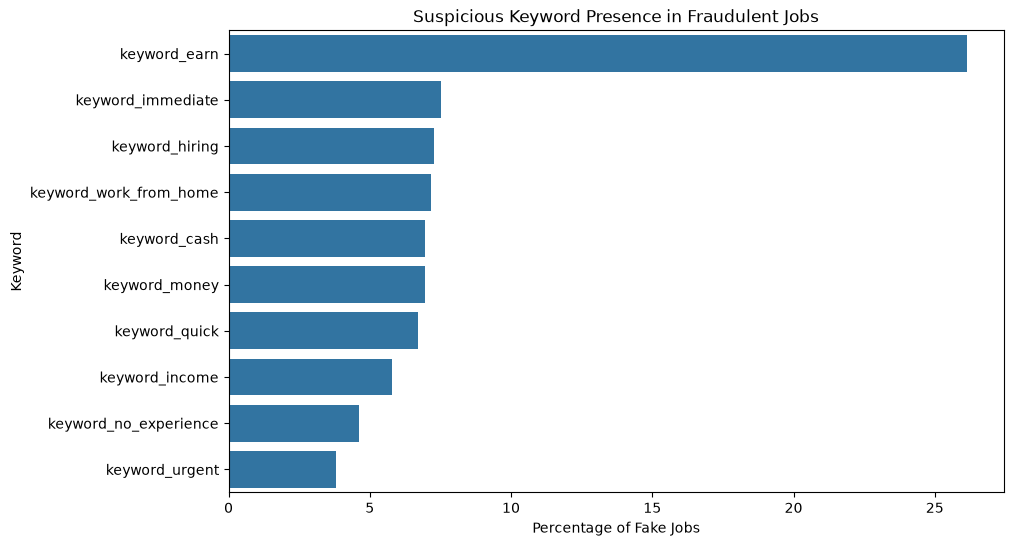

In [138]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=keyword_fake_rates.values,
    y=keyword_fake_rates.index
)

plt.title("Suspicious Keyword Presence in Fraudulent Jobs")
plt.xlabel("Percentage of Fake Jobs")
plt.ylabel("Keyword")

plt.show()

# Text Analysis — Findings

We analyzed the textual characteristics of job postings using:

- Title length
- Description length
- Requirements length
- Benefits length
- Company profile length
- Word frequency
- Word clouds
- Suspicious keyword presence

The analysis showed differences in text characteristics between legitimate
and fraudulent job postings.

Text length features may provide useful numerical signals for the model.
Word-frequency analysis also revealed differences in commonly used terms
between the two classes.

Suspicious keywords were analyzed as potential signals rather than direct
proof of fraudulent activity.

In [139]:
numeric_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "has_salary",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "missing_info_count",
    "title_length",
    "description_length",
    "requirements_length",
    "benefits_length",
    "company_profile_length"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
telecommuting,17879.0,0.042899,0.202636,0.0,0.0,0.0,0.0,1.0
has_company_logo,17879.0,0.795346,0.403459,0.0,1.0,1.0,1.0,1.0
has_questions,17879.0,0.491750,0.499946,0.0,0.0,0.0,1.0,1.0
has_salary,17879.0,0.160412,0.366998,0.0,0.0,0.0,0.0,1.0
has_company_profile,17879.0,0.815034,0.388281,0.0,1.0,1.0,1.0,1.0
has_requirements,17879.0,0.849153,0.357910,0.0,1.0,1.0,1.0,1.0
has_benefits,17879.0,0.596230,0.490666,0.0,0.0,1.0,1.0,1.0
missing_info_count,17879.0,1.579171,0.955190,0.0,1.0,1.0,2.0,4.0
title_length,17879.0,28.531126,13.871218,3.0,19.0,25.0,35.0,142.0
description_length,17879.0,1218.072543,894.807276,6.0,607.0,1017.0,1586.0,14907.0


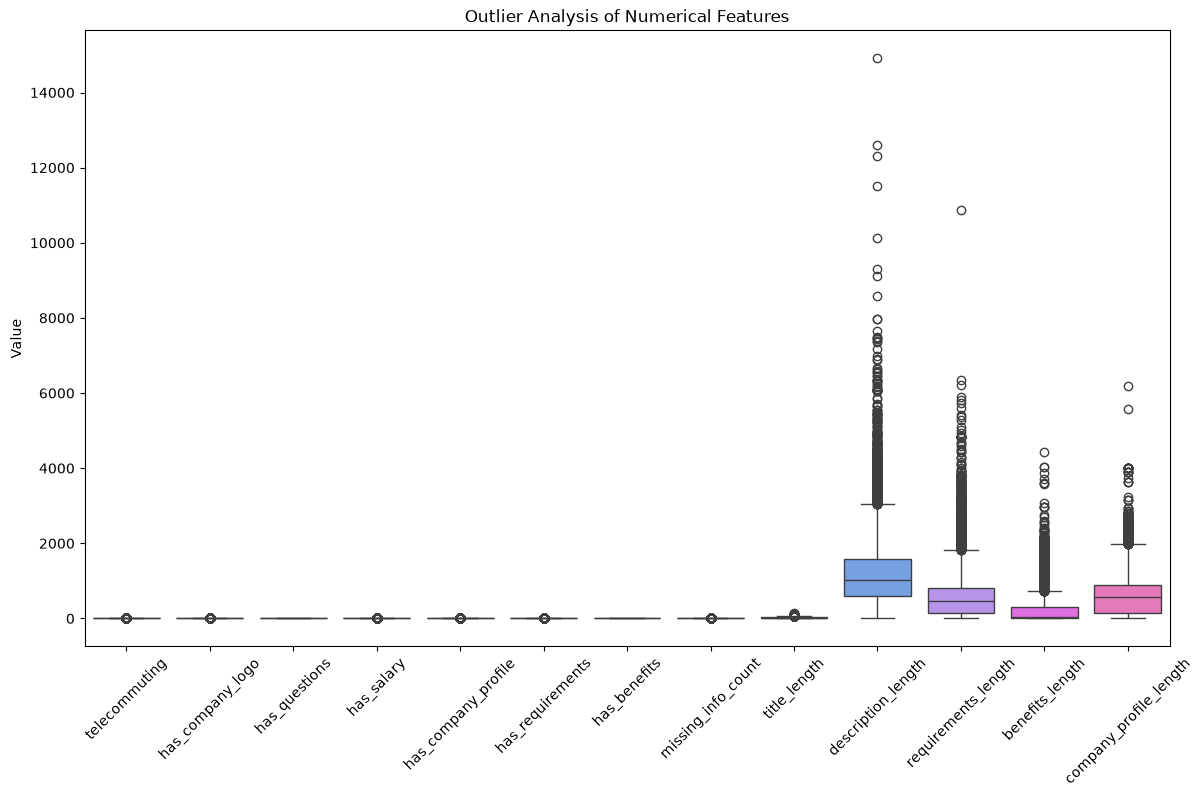

In [140]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df[numeric_features]
)

plt.title("Outlier Analysis of Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.show()

In [141]:
def get_outlier_count(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = (
        (data[column] < lower) |
        (data[column] > upper)
    ).sum()

    return count, lower, upper

In [142]:
for col in [
    "title_length",
    "description_length",
    "requirements_length",
    "benefits_length",
    "company_profile_length"
]:
    
    count, lower, upper = get_outlier_count(df, col)
    
    print(f"\n{col}")
    print("Outliers:", count)
    print("Lower:", lower)
    print("Upper:", upper)


title_length
Outliers: 730
Lower: -5.0
Upper: 59.0

description_length
Outliers: 718
Lower: -861.5
Upper: 3054.5

requirements_length
Outliers: 673
Lower: -865.0
Upper: 1831.0

benefits_length
Outliers: 1355
Lower: -441.0
Upper: 735.0

company_profile_length
Outliers: 525
Lower: -973.5
Upper: 1990.5


In [143]:
df.loc[
    df["description_length"].nlargest(10).index,
    ["title", "description_length", "fraudulent"]
]

,title,description_length,fraudulent
4778,Drinking Water/Wastewater Operator,14907,0
12746,Operating Room Technician,12604,0
8719,Dialysis Equipment Technician,12302,0
13197,Patient Advocate,11515,0
14200,Cardiovascular Technologist,10124,0
10335,Mission Operations / Open Positions,9295,0
12996,Specimen Preparation/Collection Tech,9110,0
6575,Project Subcontracting Manager,8578,1
214,Recruiter/Recruiting Assistant,7967,0
1327,Recruiter/Recruiting Assistant,7967,0


In [144]:
correlation_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "has_salary",
    "has_company_profile",
    "has_requirements",
    "has_benefits",
    "missing_info_count",
    "title_length",
    "description_length",
    "requirements_length",
    "benefits_length",
    "company_profile_length",
    "fraudulent"
]

In [145]:
correlation_matrix = df[correlation_features].corr()

correlation_matrix

,telecommuting,has_company_logo,has_questions,has_salary,has_company_profile,has_requirements,has_benefits,missing_info_count,title_length,description_length,requirements_length,benefits_length,company_profile_length,fraudulent
telecommuting,1.000000,-0.019862,0.020334,0.071427,-0.065498,0.036788,0.054958,-0.042834,0.003893,-0.006187,0.016660,0.001611,-0.023932,0.034594
has_company_logo,-0.019862,1.000000,0.233855,-0.058196,0.694191,0.256834,0.193435,-0.455426,0.006011,0.005302,0.114583,0.149212,0.457802,-0.261655
has_questions,0.020334,0.233855,1.000000,0.005079,0.153933,0.219521,0.281591,-0.291428,0.013473,-0.010977,0.042264,0.093507,0.115741,-0.091436
has_salary,0.071427,-0.058196,0.005079,1.000000,-0.086168,0.075216,0.129843,-0.444069,-0.004354,0.018478,0.034547,0.094336,-0.004009,0.059838
has_company_profile,-0.065498,0.694191,0.153933,-0.086168,1.000000,0.102293,0.099744,-0.462955,0.037973,0.010928,0.083981,0.091972,0.521301,-0.286002
has_requirements,0.036788,0.256834,0.219521,0.075216,0.102293,1.000000,0.426175,-0.664100,0.043043,-0.116865,0.405662,0.225246,0.121494,-0.016400
has_benefits,0.054958,0.193435,0.281591,0.129843,0.099744,0.426175,1.000000,-0.763805,0.039992,-0.071323,0.066409,0.510019,0.072547,-0.007299
missing_info_count,-0.042834,-0.455426,-0.291428,-0.444069,-0.462955,-0.664100,-0.763805,1.000000,-0.050435,0.068885,-0.233526,-0.420020,-0.293156,0.103163
title_length,0.003893,0.006011,0.013473,-0.004354,0.037973,0.043043,0.039992,-0.050435,1.000000,-0.025489,0.000463,-0.020497,-0.006899,0.035021
description_length,-0.006187,0.005302,-0.010977,0.018478,0.010928,-0.116865,-0.071323,0.068885,-0.025489,1.000000,0.089071,0.066847,0.117453,-0.015599


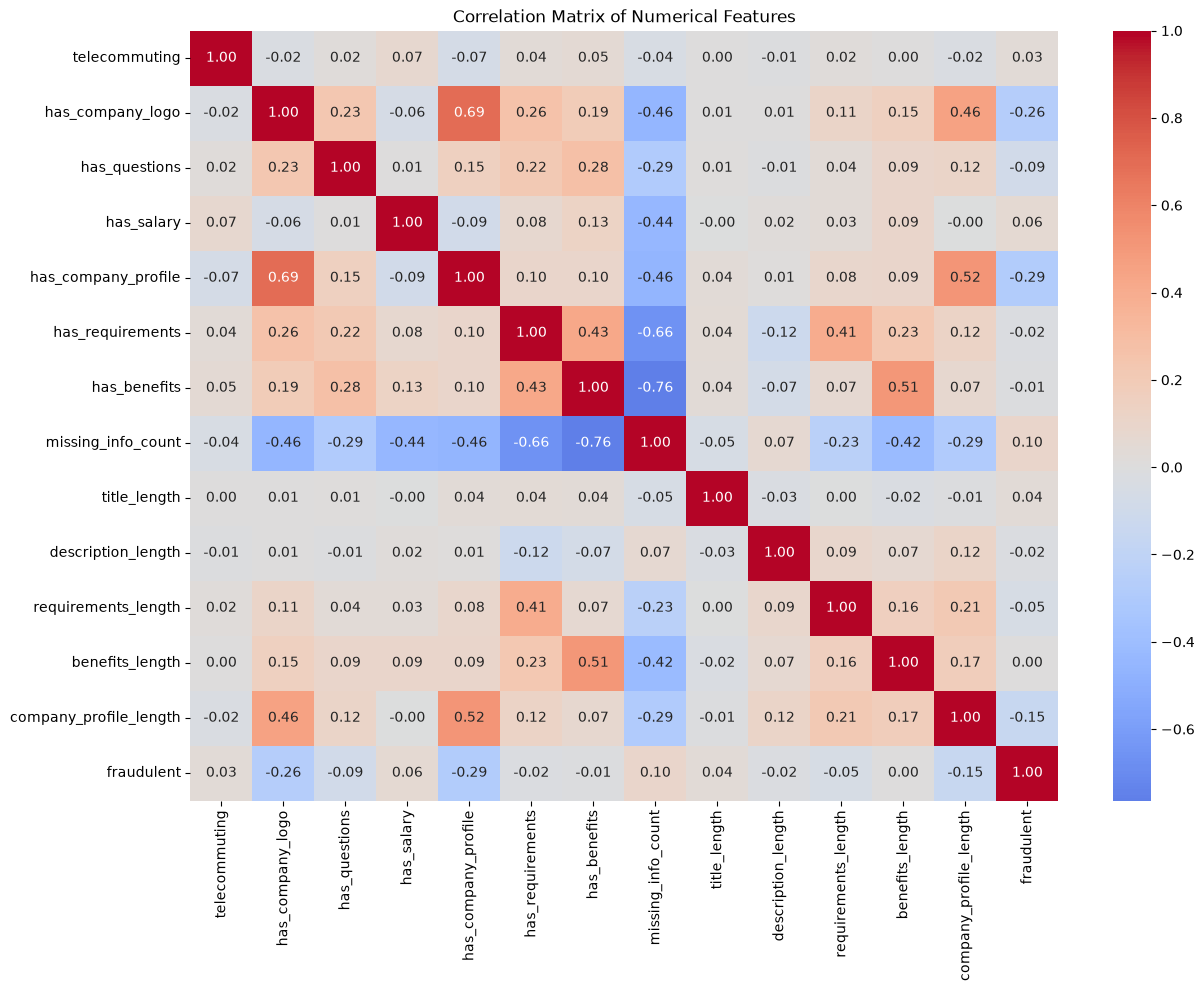

In [146]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [147]:
print("Dataset Shape:", df.shape)

Dataset Shape: (17879, 42)


In [148]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [149]:
df = df.drop_duplicates().copy()

In [150]:
print("Duplicates After Cleaning:", df.duplicated().sum())

Duplicates After Cleaning: 0


In [151]:
print(df["fraudulent"].value_counts())

fraudulent
0    17014
1      865
Name: count, dtype: int64


In [152]:
print(df["fraudulent"].unique())

[0 1]


In [153]:
null_summary = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

null_summary[null_summary["Missing"] > 0]

,Missing,Percentage
salary_range,15011,83.958834


In [154]:
df.dtypes

job_id                    int64
title                       str
location                    str
department                  str
salary_range                str
company_profile             str
description                 str
requirements                str
benefits                    str
telecommuting             int64
has_company_logo          int64
has_questions             int64
employment_type             str
required_experience         str
required_education          str
industry                    str
function                    str
fraudulent                int64
has_salary                int64
has_company_profile       int64
has_requirements          int64
has_benefits              int64
missing_info_count        int64
title_length              int64
description_length        int64
requirements_length       int64
benefits_length           int64
company_profile_length    int64
keyword_urgent            int64
keyword_immediate         int64
keyword_easy              int64
keyword_

In [155]:
for col in text_columns:
    empty_count = (df[col].str.strip() == "").sum()
    print(f"{col}: {empty_count} empty values")

title: 0 empty values
company_profile: 3307 empty values
description: 1 empty values
requirements: 2697 empty values
benefits: 7219 empty values


In [156]:
df = df[df["description"].notna()].copy()

df = df[
    df["description"].str.strip() != ""
].copy()

In [157]:
import re

def clean_text(text):
    text = str(text).lower()
    
    # HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [158]:
for col in text_columns:
    df[col] = df[col].apply(clean_text)

In [159]:
output_path = "../data/processed/clean_data.csv"

df.to_csv(
    output_path,
    index=False
)

print("Clean dataset saved successfully!")
print(output_path)

Clean dataset saved successfully!
../data/processed/clean_data.csv


In [160]:
import os

print(
    "File exists:",
    os.path.exists(output_path)
)

File exists: True


In [161]:
clean_df = pd.read_csv(output_path)

print("Shape:", clean_df.shape)

clean_df.head()

Shape: (17878, 42)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,keyword_cash,keyword_earn,keyword_guaranteed,keyword_work_from_home,keyword_no_experience,keyword_quick,keyword_hiring,keyword_investment,keyword_income,keyword_commission
0,1,marketing intern,"US, NY, New York",Marketing,NaN,"we're food52, and we've created a groundbreaki...","food52, a fast-growing, james beard award-winn...",experience with content management systems a m...,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,2,customer service - cloud video production,"NZ, , Auckland",Success,NaN,"90 seconds, the worlds cloud video production ...",organised - focused - vibrant - awesome!do you...,what we expect from you:your key responsibilit...,what you will get from usthrough being part of...,0,...,0,1,0,0,0,1,0,0,0,1
2,3,commissioning machinery assistant (cma),"US, IA, Wever",Unknown,NaN,valor services provides workforce solutions th...,"our client, located in houston, is actively se...",implement pre-commissioning and commissioning ...,NaN,0,...,0,0,0,0,0,0,0,0,0,1
3,4,account executive - washington dc,"US, DC, Washington",Sales,NaN,our passion for improving quality of life thro...,the company: esri – environmental systems rese...,"education: bachelor’s or master’s in gis, busi...",our culture is anything but corporate—we have ...,0,...,0,0,0,0,0,0,0,0,0,0
4,5,bill review manager,"US, FL, Fort Worth",Unknown,NaN,spotsource solutions llc is a global human cap...,job title: itemization review managerlocation:...,qualifications:rn license in the state of texa...,full benefits offered,0,...,0,0,0,0,0,0,1,0,0,0


In [162]:
clean_df.isnull().sum()

job_id                        0
title                         0
location                      0
department                    0
salary_range              15011
company_profile            3307
description                   0
requirements               2697
benefits                   7219
telecommuting                 0
has_company_logo              0
has_questions                 0
employment_type               0
required_experience           0
required_education            0
industry                      0
function                      0
fraudulent                    0
has_salary                    0
has_company_profile           0
has_requirements              0
has_benefits                  0
missing_info_count            0
title_length                  0
description_length            0
requirements_length           0
benefits_length               0
company_profile_length        0
keyword_urgent                0
keyword_immediate             0
keyword_easy                  0
keyword_

In [163]:
print("Description NULL:", df["description"].isnull().sum())

print(
    "Description Empty:",
    (df["description"].str.strip() == "").sum()
)

Description NULL: 0
Description Empty: 0


In [164]:
print("=" * 50)
print("FINAL DATA QUALITY CHECK")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Values:")
print(df["fraudulent"].value_counts())

print("\nTarget Unique Values:")
print(df["fraudulent"].unique())

print("\nRemaining NULL Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nEmpty Text Values:")
for col in text_columns:
    empty_count = (df[col].fillna("").str.strip() == "").sum()
    print(f"{col}: {empty_count}")

FINAL DATA QUALITY CHECK

Shape:
(17878, 42)

Duplicate Rows:
0

Target Values:
fraudulent
0    17014
1      864
Name: count, dtype: int64

Target Unique Values:
[0 1]

Remaining NULL Values:
salary_range    15011
dtype: int64

Empty Text Values:
title: 0
company_profile: 3307
description: 0
requirements: 2697
benefits: 7219


# Final EDA Summary

## Dataset Overview

The Fake Job Postings dataset contains job-posting information along with
a binary target variable indicating whether a posting is fraudulent.

## Data Cleaning

The following preprocessing steps were performed:

- Removed the single record with a missing job description.
- Filled missing text fields with empty strings.
- Filled missing categorical values with `Unknown`.
- Preserved missing salary information because its absence may itself be
  informative.
- Created availability indicators such as `has_salary`,
  `has_company_profile`, `has_requirements`, and `has_benefits`.
- Checked duplicate records.
- Investigated potential outliers without blindly removing legitimate values.
- Cleaned textual data by handling HTML, URLs, email addresses and
  unnecessary whitespace.

## Exploratory Data Analysis

The following areas were analyzed:

- Target class distribution
- Class imbalance
- Employment type
- Required experience
- Required education
- Industry
- Function
- Location
- Department
- Salary availability
- Company profile availability
- Requirements availability
- Benefits availability
- Missing information count
- Text length
- Word frequency
- Suspicious keywords
- Numerical feature correlations

## Key Findings

The analysis identified differences between legitimate and fraudulent
job postings across several textual, categorical and information-availability
features.

Missing information and textual characteristics may provide useful signals
for detecting fraudulent job postings.

However, observed associations do not necessarily imply causation.

## Dataset Ready for Modeling

The cleaned dataset has been saved as:

`data/processed/clean_data.csv`

The next stage will involve feature engineering, train-test splitting,
text vectorization and machine learning model development.